In [1]:
import sys, os, gc
sys.path.insert(0, os.path.abspath('..'))
import torch, numpy as np, cv2, torch.nn as nn
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
DATA_DIR  = Path('../datasets/train_subset')
MODEL_DIR = Path('../models')
print('Device:', DEVICE)
print('real:', len(list((DATA_DIR/'real').glob('*.mp4'))))
print('fake:', len(list((DATA_DIR/'fake').glob('*.mp4'))))
for w in ['spatial_probe.pt']:
    print('✔' if (MODEL_DIR/w).exists() else '✘ MISSING', w)

Device: mps
real: 200
fake: 200
✔ spatial_probe.pt


In [2]:
class DINOv2Probe(nn.Module):
    def __init__(self, d=768):
        super().__init__()
        self.probe = nn.Sequential(nn.LayerNorm(d),nn.Linear(d,128),nn.GELU(),nn.Dropout(0.2),nn.Linear(128,1),nn.Sigmoid())
    def forward(self,x): return self.probe(x)

dino = AutoModel.from_pretrained('facebook/dinov2-base').eval().to(DEVICE)
for p in dino.parameters(): p.requires_grad=False
probe = DINOv2Probe().to(DEVICE)
probe.load_state_dict(torch.load(MODEL_DIR/'spatial_probe.pt', map_location=DEVICE))
probe.eval()
print('✔ Models loaded')

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✔ Models loaded


In [3]:
T = transforms.Compose([
    transforms.ToPILImage(), transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def score_video(path, n=8):
    cap = cv2.VideoCapture(str(path))
    total = max(1, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    scores = []
    for i in np.linspace(0, total-1, min(n,total), dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if ok:
            t = T(f[:,:,::-1].copy()).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                feat = dino(t).last_hidden_state[:,0]
                scores.append(probe(feat).item())
            del t, feat
            if DEVICE=="mps": torch.mps.empty_cache()
    cap.release()
    return float(np.mean(scores)) if scores else 0.5

probs, labels = [], []
real_vids = sorted((DATA_DIR/"real").glob("*.mp4"))
fake_vids = sorted((DATA_DIR/"fake").glob("*.mp4"))
print(f"Scoring {len(real_vids)} real + {len(fake_vids)} fake videos...")
for v in real_vids:
    probs.append(score_video(v)); labels.append(0)
    print(f"  real {v.name}: {probs[-1]:.3f}")
for v in fake_vids:
    probs.append(score_video(v)); labels.append(1)
    print(f"  fake {v.name}: {probs[-1]:.3f}")
probs=np.array(probs); labels=np.array(labels); preds=(probs>0.5).astype(int)
print("Done")

Scoring 200 real + 200 fake videos...
  real 008.mp4: 0.000
  real 009.mp4: 0.001
  real 020.mp4: 0.002
  real 021.mp4: 0.002
  real 022.mp4: 0.000
  real 023.mp4: 0.021
  real 026.mp4: 0.126
  real 027.mp4: 0.000
  real 032.mp4: 0.001
  real 033.mp4: 0.002
  real 034.mp4: 0.004
  real 035.mp4: 0.004
  real 036.mp4: 0.104
  real 037.mp4: 0.002
  real 140.mp4: 0.779
  real 141.mp4: 0.002
  real 142.mp4: 0.000
  real 143.mp4: 0.001
  real 146.mp4: 0.002
  real 147.mp4: 0.000
  real 152.mp4: 0.033
  real 153.mp4: 0.001
  real 154.mp4: 0.015
  real 155.mp4: 0.673
  real 156.mp4: 0.005
  real 157.mp4: 0.040
  real 168.mp4: 0.004
  real 169.mp4: 0.001
  real 180.mp4: 0.010
  real 181.mp4: 0.012
  real 182.mp4: 0.002
  real 183.mp4: 0.000
  real 184.mp4: 0.000
  real 185.mp4: 0.001
  real 190.mp4: 0.001
  real 191.mp4: 0.003
  real 194.mp4: 0.003
  real 195.mp4: 0.000
  real 196.mp4: 0.000
  real 197.mp4: 0.011
  real 208.mp4: 0.000
  real 209.mp4: 0.035
  real 218.mp4: 0.003
  real 219.mp4: 

Accuracy : 0.9775 (97.8%)
AUC-ROC  : 0.9981
F1 Score : 0.9780
              precision    recall  f1-score   support

        Real       1.00      0.95      0.98       200
        Fake       0.96      1.00      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



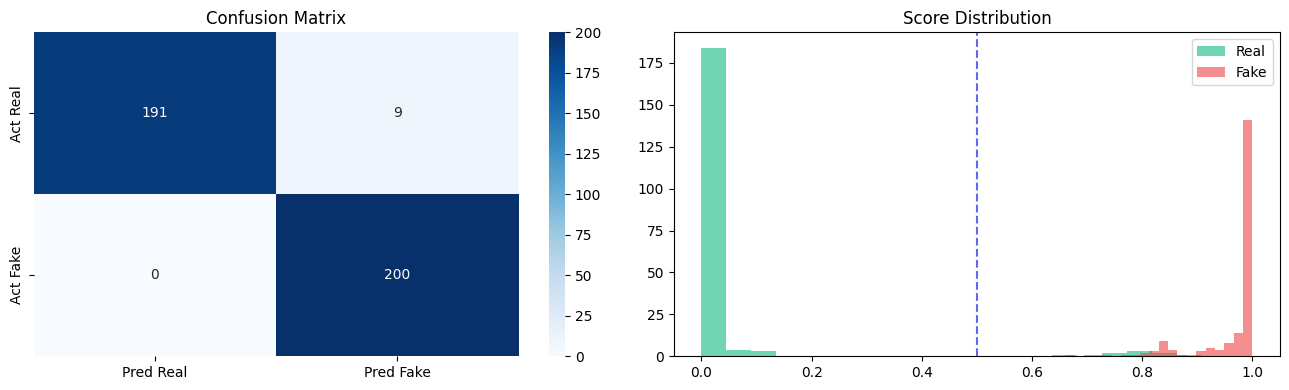

In [4]:
acc = accuracy_score(labels, preds)
f1  = f1_score(labels, preds)
try: auc = roc_auc_score(labels, probs)
except: auc = float("nan")
print(f"Accuracy : {acc:.4f} ({acc*100:.1f}%)")
print(f"AUC-ROC  : {auc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(classification_report(labels, preds, target_names=["Real","Fake"]))

fig,axes=plt.subplots(1,2,figsize=(13,4))
cm=confusion_matrix(labels,preds)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Pred Real","Pred Fake"],yticklabels=["Act Real","Act Fake"],ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[1].hist(probs[labels==0],bins=20,alpha=0.6,color="#10b981",label="Real")
axes[1].hist(probs[labels==1],bins=20,alpha=0.6,color="#ef4444",label="Fake")
axes[1].axvline(0.5,color="#6366f1",linestyle="--")
axes[1].set_title("Score Distribution"); axes[1].legend()
plt.tight_layout(); plt.savefig("../docs/benchmark.png",dpi=150); plt.show()